# Strategic Deployment of NIDS in IoT: Technical & Ethical Framework  
**Objective:** To develop a Network Intrusion Detection System (NIDS) that balances high-fidelity threat detection with environmental sustainability and the reduction of analyst "Alert Fatigue."

In [5]:
import os

# Delete the old metrics table for a clean reset

if os.path.exists("results/master_comparison_table.csv"):
    os.remove("results/master_comparison_table.csv")
    print("Old metrics table cleared. Ready for fresh run.")

In [6]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from codecarbon import EmissionsTracker

In [7]:
# ==========================================
# Helper Functions for Model Evaluation
# ==========================================
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Automatically create your beautiful folder structure!
os.makedirs("models", exist_ok=True)
os.makedirs("results/classification_reports", exist_ok=True)
os.makedirs("results/confusion_matrices", exist_ok=True)
os.makedirs("results/sustainability", exist_ok=True)

def saveModel(model_name, clf):
    filepath = f"models/{model_name}.sav"
    with open(filepath, 'wb') as f:
        pickle.dump(clf, f)
    print(f"✅ Model successfully saved to {filepath}")

def saveMasterMetrics(model_name, accuracy, precision, recall, f1):
    filepath = "results/master_comparison_table.csv"
    new_data = pd.DataFrame([{
        "Model": model_name,
        "Accuracy (%)": round(accuracy * 100, 2),
        "Precision (%)": round(precision * 100, 2),
        "Recall (%)": round(recall * 100, 2),
        "F1-Score (%)": round(f1 * 100, 2)
    }])
    if not os.path.isfile(filepath):
        new_data.to_csv(filepath, index=False)
    else:
        new_data.to_csv(filepath, mode='a', header=False, index=False)
    print(f"📊 Metrics appended to {filepath}")

def plot_confusion_matrix(model_name, y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.tight_layout()
    # Updated file path!
    filepath = f"results/confusion_matrices/{model_name}_confusion_matrix.png"
    plt.savefig(filepath, dpi=300)
    print(f"✅ Confusion Matrix saved to {filepath}")
    plt.show()

def saveClassificationReport(model_name, y_test, y_pred):
    report = classification_report(y_test, y_pred)
    # Updated file path!
    filepath = f"results/classification_reports/{model_name}_classification_report.txt"
    with open(filepath, 'w') as f:
        f.write(f"Classification Report: {model_name}\n")
        f.write("="*60 + "\n")
        f.write(report)
    print(f"✅ Classification Report saved to {filepath}")


In [8]:
# Data Loading & Initial Prep 

import pandas as pd

print("Loading dataset...")
df = pd.read_csv('data/IoT_Intrusion.csv')

# Randomly sample 10% of the dataset to prevent memory crashes
df = df.sample(frac=0.1, random_state=42)

print(f"Original number of classes: {df['label'].nunique()}")

# Use a for loop to group the 34 classes into 8 main categories
new_labels = []
for label in df['label']:
    if label.startswith('DDoS'):
        new_labels.append('DDoS')
    elif label.startswith('DoS'):
        new_labels.append('DoS')
    elif label.startswith('Mirai'):
        new_labels.append('Mirai')
    elif label.startswith('Recon') or label == 'VulnerabilityScan':
        new_labels.append('Recon')
    elif 'Spoofing' in label:
        new_labels.append('Spoofing')
    elif label == 'DictionaryBruteForce':
        new_labels.append('BruteForce')
    elif label == 'BenignTraffic':
        new_labels.append('BenignTraffic')
    else:
        # Catch all remaining attacks (XSS, SqlInjection, CommandInjection, 
        # Uploading_Attack, BrowserHijacking, Backdoor_Malware)
        new_labels.append('Web_based')

# Replace the original label column with new grouped categories
df['label'] = new_labels

print(f"Grouping complete! We now have {df['label'].nunique()} main categories.")
print("\nNew Class Distribution:")
print(df['label'].value_counts())


Loading dataset...
Original number of classes: 34
Grouping complete! We now have 8 main categories.

New Class Distribution:
label
DDoS             76443
DoS              18135
Mirai             5911
BenignTraffic     2366
Spoofing          1113
Recon              803
Web_based           56
BruteForce          31
Name: count, dtype: int64


In [9]:
# Scaling, Splitting, and Pickling 

print("Preparing features and labels...")
# Define df_features and df_label
df_features = df.drop(columns=['label'])
df_label = df['label']

print("Splitting data...")
# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    df_features, 
    df_label, 
    test_size=0.2, 
    random_state=42
)

print("Scaling features...")
# Fit the scaler using the training data to prevent data leakage
transformer = MinMaxScaler().fit(X_train)

# Transform both train and test sets using those learned rules
X_train = pd.DataFrame(transformer.transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(transformer.transform(X_test), columns=X_test.columns)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

print("Saving (pickling) files to the /models directory...")
# Save splits as .sav files for future scripts
with open('models/X_train.sav', 'wb') as f:
    pickle.dump(X_train, f)

with open('models/X_test.sav', 'wb') as f:
    pickle.dump(X_test, f)

with open('models/y_train.sav', 'wb') as f:
    pickle.dump(y_train, f)

with open('models/y_test.sav', 'wb') as f:
    pickle.dump(y_test, f)

with open('models/scaler.sav', 'wb') as f:
    pickle.dump(transformer, f)

print("Success! Everything is scaled, split, and saved.")


Preparing features and labels...
Splitting data...
Scaling features...
Training set size: 83886 samples
Testing set size: 20972 samples
Saving (pickling) files to the /models directory...
Success! Everything is scaled, split, and saved.


In [10]:
# Addressing Imbalance (SMOTE)
from imblearn.over_sampling import SMOTE
import pickle

print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())

print("\nApplying SMOTE (this might take a minute depending on your computer's speed)...")
# Adding a random_state to get the exact same results every time 
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print("\nClass distribution AFTER SMOTE:")
print(y_train_smote.value_counts())

# Save balanced SMOTE datasets
print("\nSaving SMOTE balanced data to the /models directory...")
with open('models/X_train_smote.sav', 'wb') as f:
    pickle.dump(X_train_smote, f)
    
with open('models/y_train_smote.sav', 'wb') as f:
    pickle.dump(y_train_smote, f)

print("Done! You are ready to train your models on the balanced data.")


Class distribution BEFORE SMOTE:
label
DDoS             61106
DoS              14537
Mirai             4726
BenignTraffic     1905
Spoofing           903
Recon              631
Web_based           51
BruteForce          27
Name: count, dtype: int64

Applying SMOTE (this might take a minute depending on your computer's speed)...

Class distribution AFTER SMOTE:
label
DDoS             61106
DoS              61106
Mirai            61106
BenignTraffic    61106
Recon            61106
Spoofing         61106
Web_based        61106
BruteForce       61106
Name: count, dtype: int64

Saving SMOTE balanced data to the /models directory...
Done! You are ready to train your models on the balanced data.


Model 1: Decision Tree

In [11]:
# ------------------------------------------
# Baseline Proof: Unbalanced Decision Tree
# ------------------------------------------

from sklearn.tree import DecisionTreeClassifier

print("Training Decision Tree on UNBALANCED data...")
# Notice we use the original X_train and y_train here, NOT the SMOTE versions!
clf_unbalanced = DecisionTreeClassifier(random_state=42)
clf_unbalanced.fit(X_train, y_train) 

print("Making predictions...")
y_pred_unbalanced = clf_unbalanced.predict(X_test)

# Use your awesome helper function to generate the evidence!
saveClassificationReport("Decision_Tree_Unbalanced", y_test, y_pred_unbalanced)


Training Decision Tree on UNBALANCED data...
Making predictions...
✅ Classification Report saved to results/classification_reports/Decision_Tree_Unbalanced_classification_report.txt


In [12]:
# ------------------------------------------
# Decision Tree Training & Sustainability Tracking
# ------------------------------------------

from sklearn.tree import DecisionTreeClassifier
from codecarbon import EmissionsTracker
import pickle

print("Starting CodeCarbon tracker...")
tracker = EmissionsTracker()
tracker.start()

print("Training Decision Tree Classifier on SMOTE data...")
# random_state ensures reproducibility across different runs
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_smote, y_train_smote) 

print("Stopping tracker...")
emissions = tracker.stop()

print(f"\n✅ Model trained successfully!")
print(f"🌍 Estimated Emissions: {emissions:.8f} kg CO2")

# Saving trained model 
saveModel("Decision_Tree", clf)

print("Model saved perfectly as 'decision_tree_model.sav'!")



Starting CodeCarbon tracker...


[codecarbon WARNING @ 23:29:10] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 23:29:12] [setup] RAM Tracking...
[codecarbon INFO @ 23:29:12] [setup] CPU Tracking...
[codecarbon WARNING @ 23:29:13] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 23:29:13] CPU Model on constant consumption mode: Intel(R) Core(TM) i5-10310U CPU @ 1.70GHz
[codecarbon WARNING @ 23:29:13] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 23:29:13] [setup] GPU Tracking...
[codecarbon INFO @ 23:29:13] No GPU found.
[codecarbon INFO @ 23:29:13] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 23:29:13] >>> Tracker's metadata:
[codecarbon I

Training Decision Tree Classifier on SMOTE data...


[codecarbon INFO @ 23:29:33] Energy consumed for RAM : 0.000044 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:29:34] Delta energy consumed for CPU with cpu_load : 0.000011 kWh, power : 2.4463623777000003 W
[codecarbon INFO @ 23:29:34] Energy consumed for All CPU : 0.000011 kWh
[codecarbon INFO @ 23:29:34] 0.000055 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:29:41] Energy consumed for RAM : 0.000064 kWh. RAM Power : 10.0 W


Stopping tracker...


[codecarbon INFO @ 23:29:41] Delta energy consumed for CPU with cpu_load : 0.000004 kWh, power : 2.2360678558125002 W
[codecarbon INFO @ 23:29:41] Energy consumed for All CPU : 0.000015 kWh
[codecarbon INFO @ 23:29:41] 0.000079 kWh of electricity and 0.000000 L of water were used since the beginning.



✅ Model trained successfully!
🌍 Estimated Emissions: 0.00001877 kg CO2
✅ Model successfully saved to models/Decision_Tree.sav
Model saved perfectly as 'decision_tree_model.sav'!


Making predictions on the test set...

=== DECISION TREE METRICS ===
Accuracy : 0.9905 (99.05%)
Precision: 0.9906 (99.06%)
Recall   : 0.9905 (99.05%)
F1-Score : 0.9905 (99.05%)
📊 Metrics appended to results/master_comparison_table.csv
✅ Confusion Matrix saved to results/confusion_matrices/Decision_Tree_confusion_matrix.png


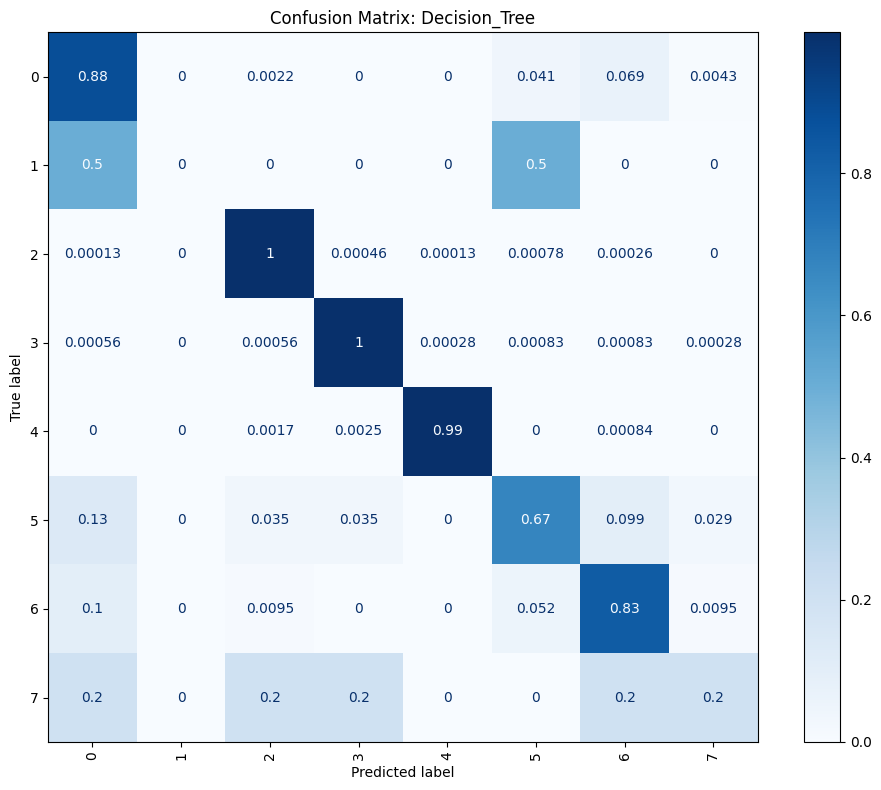

✅ Classification Report saved to results/classification_reports/Decision_Tree_classification_report.txt


c:\Users\hkval\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hkval\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hkval\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [13]:
# ------------------------------------------
# Decision Tree Model Evaluation
# ------------------------------------------

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

print("Making predictions on the test set...")
y_pred_dt = clf.predict(X_test)

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)

print("\n=== DECISION TREE METRICS ===")
print(f"Accuracy : {accuracy_dt:.4f} ({(accuracy_dt*100):.2f}%)")
print(f"Precision: {precision_dt:.4f} ({(precision_dt*100):.2f}%)")
print(f"Recall   : {recall_dt:.4f} ({(recall_dt*100):.2f}%)")
print(f"F1-Score : {f1_dt:.4f} ({(f1_dt*100):.2f}%)")

saveMasterMetrics("Decision_Tree", accuracy_dt, precision_dt, recall_dt, f1_dt)
plot_confusion_matrix("Decision_Tree", y_test, y_pred_dt)
saveClassificationReport("Decision_Tree", y_test, y_pred_dt)


Model 2: Random Forest

In [14]:
# ------------------------------------------
# Baseline Proof: Unbalanced Random Forest
# ------------------------------------------

from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest on UNBALANCED data...")
rf_unbalanced = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_unbalanced.fit(X_train, y_train) # Using original X_train

print("Making predictions...")
y_pred_rf_unb = rf_unbalanced.predict(X_test)

# Save the evidence
saveClassificationReport("Random_Forest_Unbalanced", y_test, y_pred_rf_unb)


Training Random Forest on UNBALANCED data...
Making predictions...
✅ Classification Report saved to results/classification_reports/Random_Forest_Unbalanced_classification_report.txt


c:\Users\hkval\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hkval\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hkval\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [15]:
# ------------------------------------------
# Random Forest Training & Sustainability Tracking
# ------------------------------------------

from sklearn.ensemble import RandomForestClassifier
from codecarbon import EmissionsTracker

print("Starting CodeCarbon tracker...")
tracker = EmissionsTracker()
tracker.start()

print("Training Random Forest Classifier on SMOTE data (This may take a few minutes)...")
# n_jobs=-1 uses all available CPU cores to speed up training
rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_clf.fit(X_train_smote, y_train_smote) 

print("Stopping tracker...")
emissions = tracker.stop()

print(f"\n✅ Random Forest trained successfully!")
print(f"🌍 Estimated Emissions: {emissions:.8f} kg CO2")

# Save trained model using helper functions
saveModel("Random_Forest", rf_clf)


[codecarbon WARNING @ 23:29:47] Multiple instances of codecarbon are allowed to run at the same time.


Starting CodeCarbon tracker...


[codecarbon INFO @ 23:29:48] [setup] RAM Tracking...
[codecarbon INFO @ 23:29:48] [setup] CPU Tracking...
[codecarbon WARNING @ 23:29:48] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 23:29:48] CPU Model on constant consumption mode: Intel(R) Core(TM) i5-10310U CPU @ 1.70GHz
[codecarbon WARNING @ 23:29:48] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 23:29:48] [setup] GPU Tracking...
[codecarbon INFO @ 23:29:48] No GPU found.
[codecarbon INFO @ 23:29:48] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 23:29:48] >>> Tracker's metadata:
[codecarbon INFO @ 23:29:48]   Platform system: Windows-10-10.0.19044-SP0
[codecarbon INFO @ 23:29:48]   Python ver

Training Random Forest Classifier on SMOTE data (This may take a few minutes)...


[codecarbon INFO @ 23:30:08] Energy consumed for RAM : 0.000045 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:30:09] Delta energy consumed for CPU with cpu_load : 0.000065 kWh, power : 14.4613874049 W
[codecarbon INFO @ 23:30:09] Energy consumed for All CPU : 0.000065 kWh
[codecarbon INFO @ 23:30:09] 0.000109 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:30:23] Energy consumed for RAM : 0.000085 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:30:24] Delta energy consumed for CPU with cpu_load : 0.000061 kWh, power : 15.0 W
[codecarbon INFO @ 23:30:24] Energy consumed for All CPU : 0.000125 kWh
[codecarbon INFO @ 23:30:24] 0.000210 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:30:38] Energy consumed for RAM : 0.000125 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:30:39] Delta energy consumed for CPU with cpu_load : 0.000060 kWh, power : 15.0 W
[codecarbon INFO @ 23:30:39] Energy consumed fo

Stopping tracker...


[codecarbon INFO @ 23:30:43] Delta energy consumed for CPU with cpu_load : 0.000009 kWh, power : 8.698567164000002 W
[codecarbon INFO @ 23:30:43] Energy consumed for All CPU : 0.000195 kWh
[codecarbon INFO @ 23:30:43] 0.000330 kWh of electricity and 0.000000 L of water were used since the beginning.



✅ Random Forest trained successfully!
🌍 Estimated Emissions: 0.00007851 kg CO2
✅ Model successfully saved to models/Random_Forest.sav


Making predictions on the test set...

=== RANDOM FOREST METRICS ===
Accuracy : 0.9911 (99.11%)
Precision: 0.9912 (99.12%)
Recall   : 0.9911 (99.11%)
F1-Score : 0.9911 (99.11%)
📊 Metrics appended to results/master_comparison_table.csv
✅ Confusion Matrix saved to results/confusion_matrices/Random_Forest_confusion_matrix.png


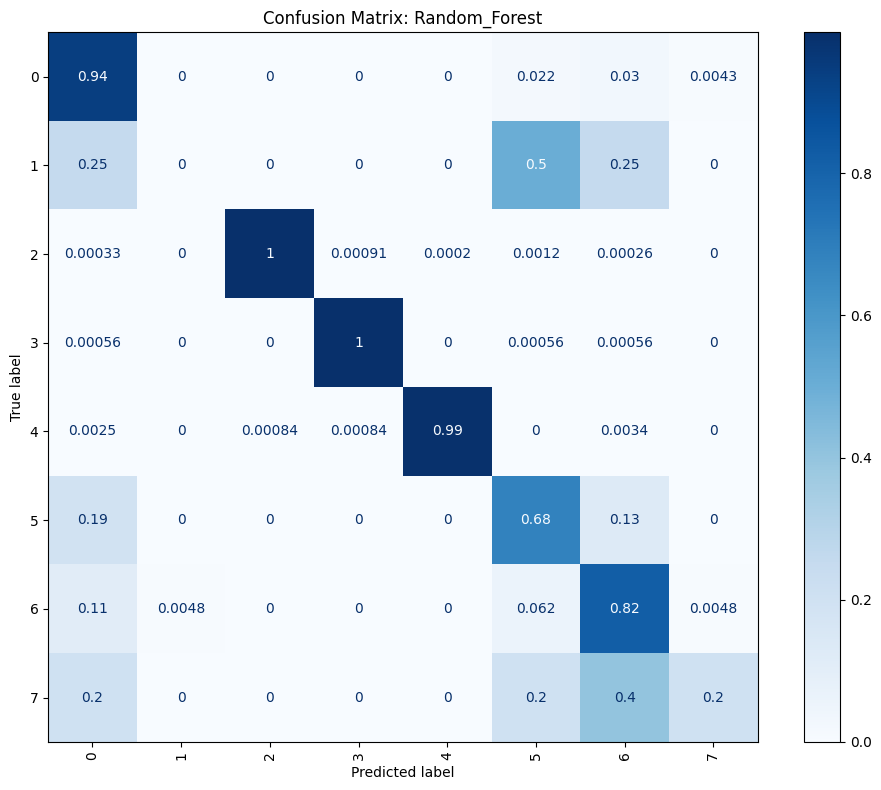

✅ Classification Report saved to results/classification_reports/Random_Forest_classification_report.txt


In [16]:
# ------------------------------------------
# Random Forest Evaluation
# ------------------------------------------

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Making predictions on the test set...")
y_pred_rf = rf_clf.predict(X_test)

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print("\n=== RANDOM FOREST METRICS ===")
print(f"Accuracy : {accuracy_rf:.4f} ({(accuracy_rf*100):.2f}%)")
print(f"Precision: {precision_rf:.4f} ({(precision_rf*100):.2f}%)")
print(f"Recall   : {recall_rf:.4f} ({(recall_rf*100):.2f}%)")
print(f"F1-Score : {f1_rf:.4f} ({(f1_rf*100):.2f}%)")

# Save accuracy and plot confusion matrix using helper functions
saveMasterMetrics("Random_Forest", accuracy_rf, precision_rf, recall_rf, f1_rf)
plot_confusion_matrix("Random_Forest", y_test, y_pred_rf)
saveClassificationReport("Random_Forest", y_test, y_pred_rf)


Model 3: Bagging Classifier

In [17]:
# ------------------------------------------
# Baseline Proof: Unbalanced Bagging Classifier
# ------------------------------------------

from sklearn.ensemble import BaggingClassifier

print("Training Bagging Classifier on UNBALANCED data...")
bag_unbalanced = BaggingClassifier(random_state=42, n_jobs=-1)
bag_unbalanced.fit(X_train, y_train) # Using original X_train

print("Making predictions...")
y_pred_bag_unb = bag_unbalanced.predict(X_test)

# Save the evidence
saveClassificationReport("Bagging_Classifier_Unbalanced", y_test, y_pred_bag_unb)


Training Bagging Classifier on UNBALANCED data...
Making predictions...
✅ Classification Report saved to results/classification_reports/Bagging_Classifier_Unbalanced_classification_report.txt


In [18]:
# ------------------------------------------
# Bagging Classifier Training & Sustainability Tracking
# ------------------------------------------

from sklearn.ensemble import BaggingClassifier
from codecarbon import EmissionsTracker

print("Starting CodeCarbon tracker...")
tracker = EmissionsTracker()
tracker.start()

print("Training Bagging Classifier on SMOTE data (This may take a few minutes)...")
# n_jobs=-1 uses all available CPU cores
bag_clf = BaggingClassifier(random_state=42, n_jobs=-1)
bag_clf.fit(X_train_smote, y_train_smote) 

print("Stopping tracker...")
emissions = tracker.stop()

print(f"\n✅ Bagging Classifier trained successfully!")
print(f"🌍 Estimated Emissions: {emissions:.8f} kg CO2")

# Save trained model using our helper function
saveModel("Bagging_Classifier", bag_clf)


[codecarbon WARNING @ 23:30:54] Multiple instances of codecarbon are allowed to run at the same time.


Starting CodeCarbon tracker...


[codecarbon INFO @ 23:30:56] [setup] RAM Tracking...
[codecarbon INFO @ 23:30:56] [setup] CPU Tracking...
[codecarbon WARNING @ 23:30:56] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 23:30:56] CPU Model on constant consumption mode: Intel(R) Core(TM) i5-10310U CPU @ 1.70GHz
[codecarbon WARNING @ 23:30:56] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 23:30:56] [setup] GPU Tracking...
[codecarbon INFO @ 23:30:56] No GPU found.
[codecarbon INFO @ 23:30:56] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 23:30:56] >>> Tracker's metadata:
[codecarbon INFO @ 23:30:56]   Platform system: Windows-10-10.0.19044-SP0
[codecarbon INFO @ 23:30:56]   Python ver

Training Bagging Classifier on SMOTE data (This may take a few minutes)...


[codecarbon INFO @ 23:31:16] Energy consumed for RAM : 0.000045 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:31:16] Delta energy consumed for CPU with cpu_load : 0.000063 kWh, power : 14.150687205299999 W
[codecarbon INFO @ 23:31:16] Energy consumed for All CPU : 0.000063 kWh
[codecarbon INFO @ 23:31:16] 0.000108 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:31:31] Energy consumed for RAM : 0.000085 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:31:31] Delta energy consumed for CPU with cpu_load : 0.000049 kWh, power : 12.2507019168 W
[codecarbon INFO @ 23:31:31] Energy consumed for All CPU : 0.000112 kWh
[codecarbon INFO @ 23:31:31] 0.000197 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:31:42] Energy consumed for RAM : 0.000115 kWh. RAM Power : 10.0 W


Stopping tracker...


[codecarbon INFO @ 23:31:43] Delta energy consumed for CPU with cpu_load : 0.000006 kWh, power : 1.8420553005000002 W
[codecarbon INFO @ 23:31:43] Energy consumed for All CPU : 0.000118 kWh
[codecarbon INFO @ 23:31:43] 0.000233 kWh of electricity and 0.000000 L of water were used since the beginning.



✅ Bagging Classifier trained successfully!
🌍 Estimated Emissions: 0.00005534 kg CO2
✅ Model successfully saved to models/Bagging_Classifier.sav


Making predictions on the test set...

=== BAGGING CLASSIFIER METRICS ===
Accuracy : 0.9915 (99.15%)
Precision: 0.9916 (99.16%)
Recall   : 0.9915 (99.15%)
F1-Score : 0.9915 (99.15%)
📊 Metrics appended to results/master_comparison_table.csv
✅ Confusion Matrix saved to results/confusion_matrices/Bagging_Classifier_confusion_matrix.png


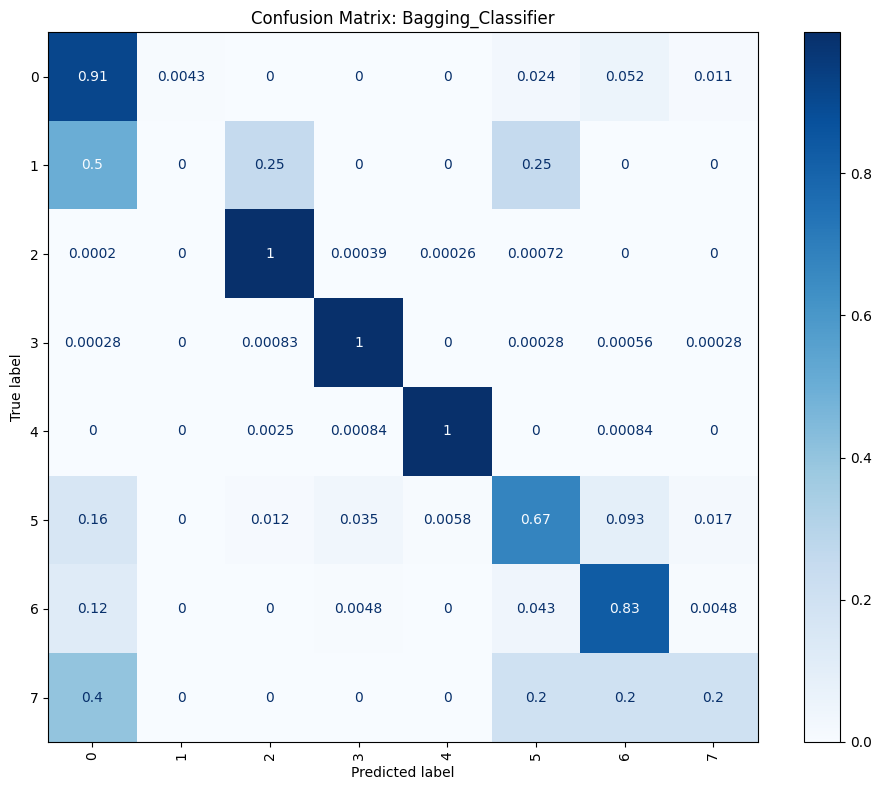

✅ Classification Report saved to results/classification_reports/Bagging_Classifier_classification_report.txt


In [19]:
# ------------------------------------------
# Bagging Classifier Evaluation
# ------------------------------------------

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Making predictions on the test set...")
y_pred_bag = bag_clf.predict(X_test)

# Calculate metrics
accuracy_bag = accuracy_score(y_test, y_pred_bag)
precision_bag = precision_score(y_test, y_pred_bag, average='weighted', zero_division=0)
recall_bag = recall_score(y_test, y_pred_bag, average='weighted', zero_division=0)
f1_bag = f1_score(y_test, y_pred_bag, average='weighted', zero_division=0)

print("\n=== BAGGING CLASSIFIER METRICS ===")
print(f"Accuracy : {accuracy_bag:.4f} ({(accuracy_bag*100):.2f}%)")
print(f"Precision: {precision_bag:.4f} ({(precision_bag*100):.2f}%)")
print(f"Recall   : {recall_bag:.4f} ({(recall_bag*100):.2f}%)")
print(f"F1-Score : {f1_bag:.4f} ({(f1_bag*100):.2f}%)")

# Save accuracy and plot confusion matrix using helper functions
saveMasterMetrics("Bagging_Classifier", accuracy_bag, precision_bag, recall_bag, f1_bag)
plot_confusion_matrix("Bagging_Classifier", y_test, y_pred_bag)
saveClassificationReport("Bagging_Classifier", y_test, y_pred_bag)

Model 4: Multi-Layer Perceptron (MLP)

In [20]:
# ------------------------------------------
# Baseline Proof: Unbalanced MLP
# ------------------------------------------

from sklearn.neural_network import MLPClassifier

print("Training MLP on UNBALANCED data (This may take a minute)...")
mlp_unbalanced = MLPClassifier(random_state=42, max_iter=800)
mlp_unbalanced.fit(X_train, y_train) # Using original X_train

print("Making predictions...")
y_pred_mlp_unb = mlp_unbalanced.predict(X_test)

# Save the evidence!
saveClassificationReport("MLP_Classifier_Unbalanced", y_test, y_pred_mlp_unb)


Training MLP on UNBALANCED data (This may take a minute)...
Making predictions...
✅ Classification Report saved to results/classification_reports/MLP_Classifier_Unbalanced_classification_report.txt


c:\Users\hkval\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hkval\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hkval\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [21]:
# ------------------------------------------
# MLP Training & Sustainability Tracking
# ------------------------------------------
from sklearn.neural_network import MLPClassifier
from codecarbon import EmissionsTracker

print("Starting CodeCarbon tracker...")
tracker = EmissionsTracker()
tracker.start()

print("Training MLP Neural Network on SMOTE data...")
print(" PLEASE BE PATIENT: 1000 iterations may take several minutes.")

# Set max_iter to 1000 to ensure the model reaches its full potential.
mlp_clf = MLPClassifier(
    random_state=42, 
    max_iter=1000, 
    hidden_layer_sizes=(100,), 
    activation='relu',
    solver='adam'
)

mlp_clf.fit(X_train_smote, y_train_smote)

print("Stopping tracker...")
emissions = tracker.stop()

print(f"\n MLP trained successfully!")
print(f" Estimated Emissions: {emissions:.8f} kg CO2")

# Save trained model
saveModel("MLP_Classifier", mlp_clf)

[codecarbon WARNING @ 23:34:45] Multiple instances of codecarbon are allowed to run at the same time.


Starting CodeCarbon tracker...


[codecarbon INFO @ 23:34:47] [setup] RAM Tracking...
[codecarbon INFO @ 23:34:47] [setup] CPU Tracking...
[codecarbon WARNING @ 23:34:47] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 23:34:47] CPU Model on constant consumption mode: Intel(R) Core(TM) i5-10310U CPU @ 1.70GHz
[codecarbon WARNING @ 23:34:47] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 23:34:47] [setup] GPU Tracking...
[codecarbon INFO @ 23:34:47] No GPU found.
[codecarbon INFO @ 23:34:47] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 23:34:47] >>> Tracker's metadata:
[codecarbon INFO @ 23:34:47]   Platform system: Windows-10-10.0.19044-SP0
[codecarbon INFO @ 23:34:47]   Python ver

Training MLP Neural Network on SMOTE data...
 PLEASE BE PATIENT: 1000 iterations may take several minutes.


[codecarbon INFO @ 23:35:07] Energy consumed for RAM : 0.000044 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:35:08] Delta energy consumed for CPU with cpu_load : 0.000007 kWh, power : 1.6237149144000003 W
[codecarbon INFO @ 23:35:08] Energy consumed for All CPU : 0.000007 kWh
[codecarbon INFO @ 23:35:08] 0.000052 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:35:22] Energy consumed for RAM : 0.000085 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:35:23] Delta energy consumed for CPU with cpu_load : 0.000007 kWh, power : 1.6408194205312503 W
[codecarbon INFO @ 23:35:23] Energy consumed for All CPU : 0.000014 kWh
[codecarbon INFO @ 23:35:23] 0.000099 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:35:37] Energy consumed for RAM : 0.000125 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:35:38] Delta energy consumed for CPU with cpu_load : 0.000008 kWh, power : 1.933383004125 W
[codecarbon INFO @

Stopping tracker...


[codecarbon INFO @ 00:03:50] Delta energy consumed for CPU with cpu_load : 0.000005 kWh, power : 1.6153809789545455 W
[codecarbon INFO @ 00:03:50] Energy consumed for All CPU : 0.000812 kWh
[codecarbon INFO @ 00:03:50] 0.005477 kWh of electricity and 0.000000 L of water were used since the beginning.



 MLP trained successfully!
 Estimated Emissions: 0.00130118 kg CO2
✅ Model successfully saved to models/MLP_Classifier.sav


Making predictions on the test set...

=== MLP METRICS ===
Accuracy : 0.7921 (79.21%)
Precision: 0.8653 (86.53%)
Recall   : 0.7921 (79.21%)
F1-Score : 0.8107 (81.07%)
📊 Metrics appended to results/master_comparison_table.csv
✅ Confusion Matrix saved to results/confusion_matrices/MLP_Classifier_confusion_matrix.png


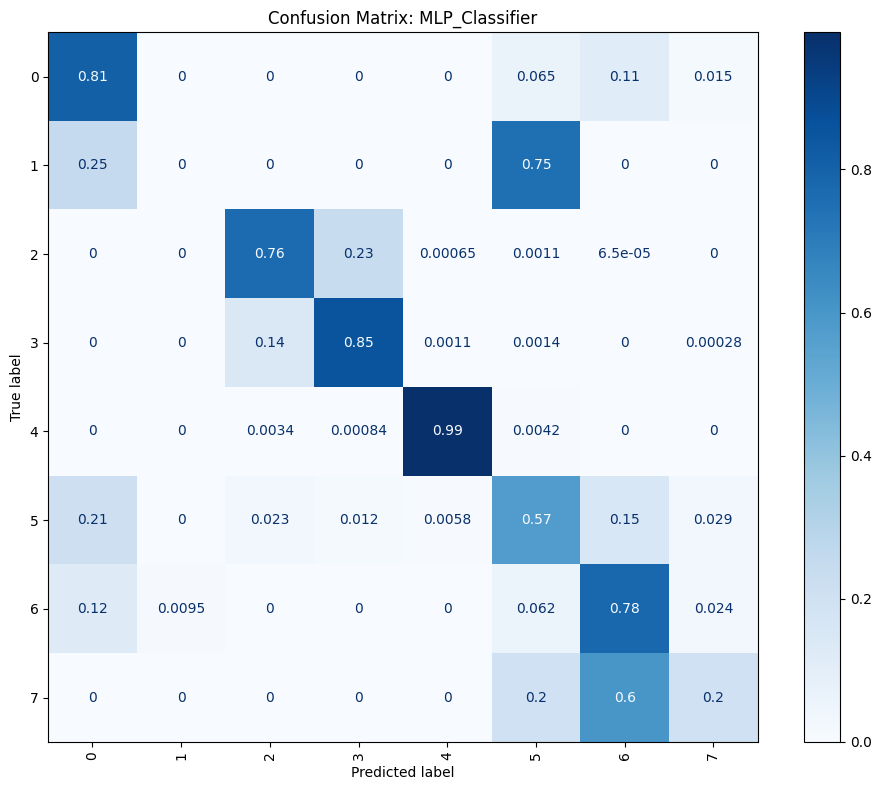

✅ Classification Report saved to results/classification_reports/MLP_Classifier_classification_report.txt


In [22]:
# ------------------------------------------
# MLP Evaluation
# ------------------------------------------

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Making predictions on the test set...")
y_pred_mlp = mlp_clf.predict(X_test)

# Calculate metrics
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
precision_mlp = precision_score(y_test, y_pred_mlp, average='weighted', zero_division=0)
recall_mlp = recall_score(y_test, y_pred_mlp, average='weighted', zero_division=0)
f1_mlp = f1_score(y_test, y_pred_mlp, average='weighted', zero_division=0)

print("\n=== MLP METRICS ===")
print(f"Accuracy : {accuracy_mlp:.4f} ({(accuracy_mlp*100):.2f}%)")
print(f"Precision: {precision_mlp:.4f} ({(precision_mlp*100):.2f}%)")
print(f"Recall   : {recall_mlp:.4f} ({(recall_mlp*100):.2f}%)")
print(f"F1-Score : {f1_mlp:.4f} ({(f1_mlp*100):.2f}%)")

# Save accuracy and plot confusion matrix using helper functions
saveMasterMetrics("MLP_Classifier", accuracy_mlp, precision_mlp, recall_mlp, f1_mlp)
plot_confusion_matrix("MLP_Classifier", y_test, y_pred_mlp)
saveClassificationReport("MLP_Classifier", y_test, y_pred_mlp)


In [23]:
# ==========================================
# Automated Evidence Collection (Size & Emissions)
# ==========================================
import os
import pandas as pd

# ------------------------------------------
# 1. Automated Model Size Log
# ------------------------------------------
print("=== MODEL SIZES (MB) ===")
# Look inside the models/ folder for .sav files
model_files = [f for f in os.listdir('models') if f.endswith('.sav')]
size_data = []

for file in model_files:
    filepath = os.path.join('models', file)
    size_mb = os.path.getsize(filepath) / (1024 * 1024) # Convert bytes to MB
    size_data.append({'Model File': file, 'Size (MB)': size_mb})

# Put it in a Pandas table and sort from smallest to largest
df_sizes = pd.DataFrame(size_data).sort_values(by='Size (MB)')
print(df_sizes.to_string(index=False))

# Save the evidence to the results folder
df_sizes.to_csv('results/sustainability/model_sizes_report.csv', index=False)
print("\n✅ Saved model sizes to results/model_sizes_report.csv")


# ------------------------------------------
# 2. Automated Carbon Emissions Log
# ------------------------------------------
print("\n=== CARBON EMISSIONS (kg CO2) ===")

if os.path.exists('emissions.csv'):
    # Load the file CodeCarbon automatically generated
    df_emissions = pd.read_csv('emissions.csv')
    
    summary_emissions = df_emissions[['timestamp', 'duration', 'emissions', 'cpu_energy', 'ram_energy']]
    
    print(summary_emissions.to_string())
    
    # Save a clean version to the results folder
    summary_emissions.to_csv('results/sustainability/carbon_emissions_summary.csv', index=False)
    print("\n✅ Saved clean emissions summary to results/carbon_emissions_summary.csv")
else:
    print("Could not find emissions.csv!")


=== MODEL SIZES (MB) ===
            Model File  Size (MB)
            scaler.sav   0.002766
    MLP_Gatekeeper.sav   0.121533
    MLP_Classifier.sav   0.182742
            y_test.sav   0.360877
     Decision_Tree.sav   0.718105
           y_train.sav   1.441012
     y_train_smote.sav   4.311131
Bagging_Classifier.sav   6.414834
            X_test.sav   7.361353
           X_train.sav  29.441160
     Random_Forest.sav 136.221997
     X_train_smote.sav 171.566326

✅ Saved model sizes to results/model_sizes_report.csv

=== CARBON EMISSIONS (kg CO2) ===
             timestamp     duration  emissions  cpu_energy  ram_energy
0  2026-05-05T23:29:41    23.990676   0.000019    0.000015    0.000064
1  2026-05-05T23:30:43    50.952731   0.000079    0.000195    0.000136
2  2026-05-05T23:31:43    43.069819   0.000055    0.000118    0.000115
3  2026-05-06T00:03:50  1738.482381   0.001301    0.000812    0.004665

✅ Saved clean emissions summary to results/carbon_emissions_summary.csv


Lite Hierarchical NIDS 

Creating Binary Labels (0 = BenignTraffic, 1 = Attack)...
Training Layer 1 MLP Gatekeeper on SMOTE binary data (This may take a minute)...
Making binary predictions on the test set...

=== LAYER 1 GATEKEEPER METRICS ===
Accuracy : 0.9927 (99.27%)
Precision: 0.9955 (99.55%)
Recall   : 0.9971 (99.71%)
F1-Score : 0.9963 (99.63%)
✅ Model successfully saved to models/MLP_Gatekeeper.sav
✅ Classification Report saved to results/classification_reports/MLP_Gatekeeper_classification_report.txt
✅ Confusion Matrix saved to results/confusion_matrices/MLP_Gatekeeper_confusion_matrix.png


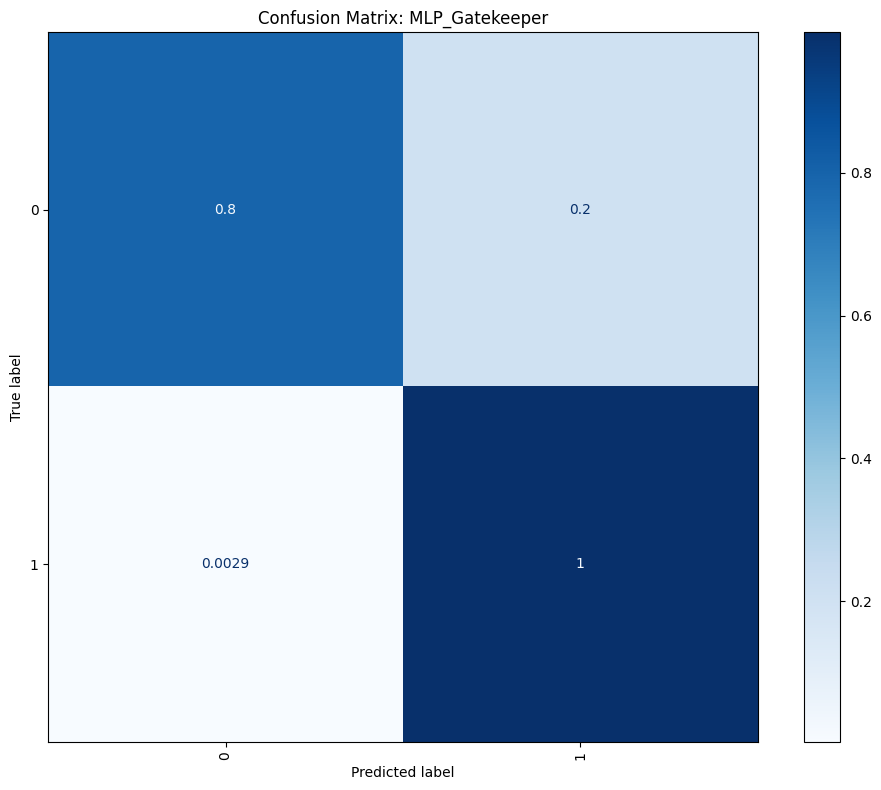

In [24]:
# ------------------------------------------
# HNIDS Phase: Layer 1 Gatekeeper (Binary Filter)
# ------------------------------------------

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Creating Binary Labels (0 = BenignTraffic, 1 = Attack)...")

# Convert labels to binary: False (0) if BenignTraffic, True (1) if Attack
y_train_binary = (y_train != 'BenignTraffic').astype(int)
y_test_binary = (y_test != 'BenignTraffic').astype(int)

# Also convert the SMOTE labels to binary to ensure balanced training
y_train_smote_binary = (y_train_smote != 'BenignTraffic').astype(int)

print("Training Layer 1 MLP Gatekeeper on SMOTE binary data (This may take a minute)...")
# Initialize the MLP Classifier for binary classification
mlp_gatekeeper = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42, early_stopping=True)

# Train the model on the SMOTE data but with binary labels
mlp_gatekeeper.fit(X_train_smote, y_train_smote_binary)

print("Making binary predictions on the test set...")
y_pred_binary = mlp_gatekeeper.predict(X_test)

# Calculate binary metrics
acc_bin = accuracy_score(y_test_binary, y_pred_binary)
# Note: average='binary' is the default, which calculates metrics for the positive class (1 = Attack)
prec_bin = precision_score(y_test_binary, y_pred_binary, zero_division=0)
rec_bin = recall_score(y_test_binary, y_pred_binary, zero_division=0)
f1_bin = f1_score(y_test_binary, y_pred_binary, zero_division=0)

print("\n=== LAYER 1 GATEKEEPER METRICS ===")
print(f"Accuracy : {acc_bin:.4f} ({(acc_bin*100):.2f}%)")
print(f"Precision: {prec_bin:.4f} ({(prec_bin*100):.2f}%)")
print(f"Recall   : {rec_bin:.4f} ({(rec_bin*100):.2f}%)")
print(f"F1-Score : {f1_bin:.4f} ({(f1_bin*100):.2f}%)")

# Use helper functions to save evidence
saveModel("MLP_Gatekeeper", mlp_gatekeeper)
saveClassificationReport("MLP_Gatekeeper", y_test_binary, y_pred_binary)
plot_confusion_matrix("MLP_Gatekeeper", y_test_binary, y_pred_binary)


Running Layer 1 Gatekeeper with 0.8 Probability Threshold...
Total original test samples        : 20972
Suspicious forwarded to Layer 2    : 20466
Benign traffic successfully dropped: 506

Running Layer 2 (Random Forest) on suspicious traffic...

=== LAYER 2 (MULTICLASS) METRICS ===
Accuracy : 0.9941 (99.41%)
Precision: 0.9946 (99.46%)
Recall   : 0.9941 (99.41%)
F1-Score : 0.9943 (99.43%)
✅ Confusion Matrix saved to results/confusion_matrices/HNIDS_Layer2_Cascade_confusion_matrix.png


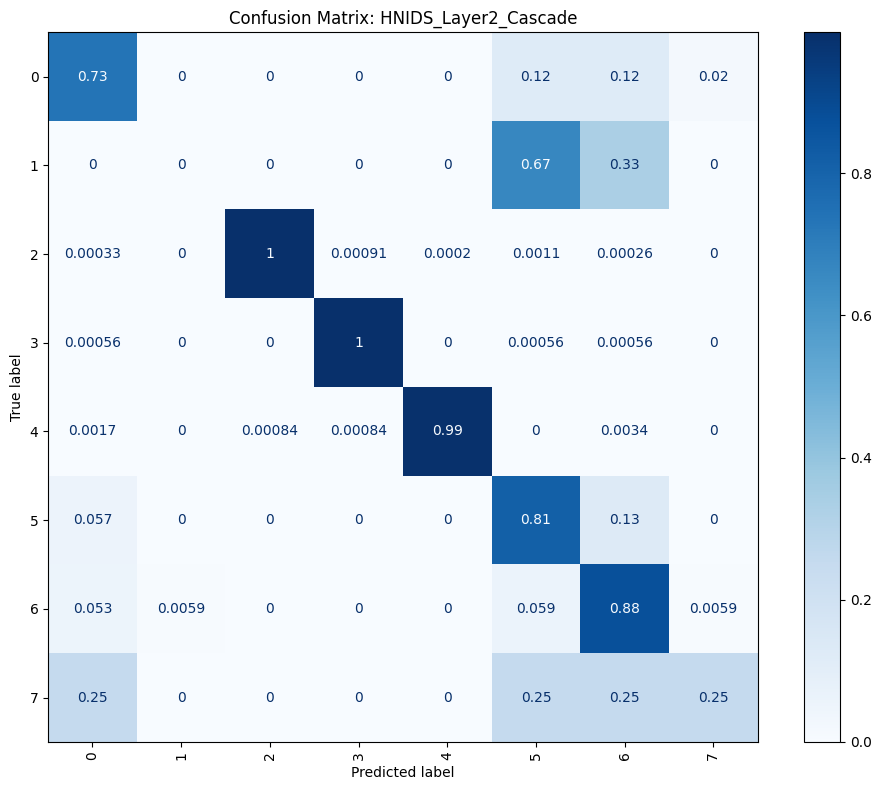

✅ Classification Report saved to results/classification_reports/HNIDS_Layer2_Cascade_classification_report.txt


In [25]:
# ==========================================
# HNIDS Phase: Step 2 Lite Cascade Logic
# ==========================================
import numpy as np

print("Running Layer 1 Gatekeeper with 0.8 Probability Threshold...")

# 1. Get PROBABILITIES from the Gatekeeper, not just predictions
# [:, 1] gets the probability of class 1 (Attack)
layer1_probs = mlp_gatekeeper.predict_proba(X_test)[:, 1]

# 2. Apply 0.8 Threshold
# If probability >= 0.8, we consider it suspicious (1). Otherwise, Benign (0).
suspicious_mask = (layer1_probs >= 0.8)

# Extract only the suspicious traffic for Layer 2
X_test_suspicious = X_test[suspicious_mask]
y_test_suspicious = y_test[suspicious_mask]

print(f"Total original test samples        : {len(X_test)}")
print(f"Suspicious forwarded to Layer 2    : {len(X_test_suspicious)}")
print(f"Benign traffic successfully dropped: {len(X_test) - len(X_test_suspicious)}")

# 3. Run Layer 2 on suspicious traffic
print("\nRunning Layer 2 (Random Forest) on suspicious traffic...")
layer2_predictions = rf_clf.predict(X_test_suspicious)

# --- Evaluate Layer 2 Specifically ---
print("\n=== LAYER 2 (MULTICLASS) METRICS ===")
acc_layer2 = accuracy_score(y_test_suspicious, layer2_predictions)
prec_layer2 = precision_score(y_test_suspicious, layer2_predictions, average='weighted', zero_division=0)
rec_layer2 = recall_score(y_test_suspicious, layer2_predictions, average='weighted', zero_division=0)
f1_layer2 = f1_score(y_test_suspicious, layer2_predictions, average='weighted', zero_division=0)

print(f"Accuracy : {acc_layer2:.4f} ({(acc_layer2*100):.2f}%)")
print(f"Precision: {prec_layer2:.4f} ({(prec_layer2*100):.2f}%)")
print(f"Recall   : {rec_layer2:.4f} ({(rec_layer2*100):.2f}%)")
print(f"F1-Score : {f1_layer2:.4f} ({(f1_layer2*100):.2f}%)")

# Save Layer 2 Evidence
plot_confusion_matrix("HNIDS_Layer2_Cascade", y_test_suspicious, layer2_predictions)
saveClassificationReport("HNIDS_Layer2_Cascade", y_test_suspicious, layer2_predictions)


Reconstructing final combined predictions for the whole system...

=== OVERALL H-NIDS SYSTEM METRICS ===
Overall Accuracy : 0.9898 (98.98%)
Overall Precision: 0.9900 (99.00%)
Overall Recall   : 0.9898 (98.98%)
Overall F1-Score : 0.9896 (98.96%)
📊 Metrics appended to results/master_comparison_table.csv
✅ Confusion Matrix saved to results/confusion_matrices/HNIDS_System_Overall_confusion_matrix.png


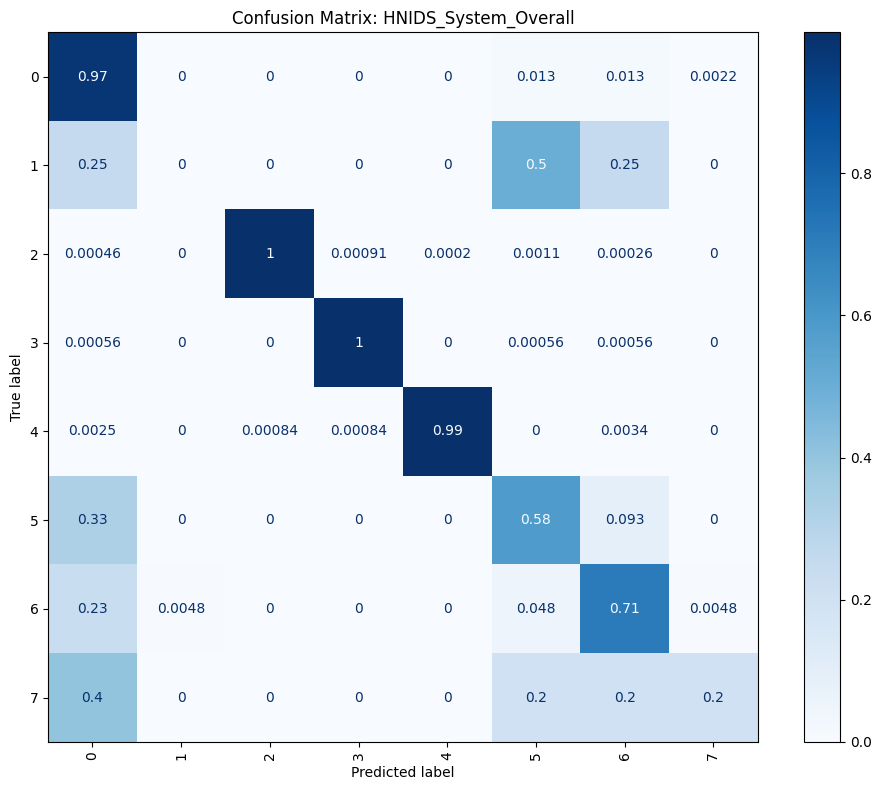

✅ Classification Report saved to results/classification_reports/HNIDS_System_Overall_classification_report.txt


In [26]:
# ==========================================
# HNIDS Phase: Step 3 Overall System Metrics
# ==========================================
print("Reconstructing final combined predictions for the whole system...")

# 1. Create an array of 'BenignTraffic' for the whole test set
final_system_predictions = np.array(['BenignTraffic'] * len(X_test), dtype=object)

# 2. Overwrite the 'suspicious' slots with whatever Layer 2 decided
final_system_predictions[suspicious_mask] = layer2_predictions

# 3. Calculate the OVERALL System Metrics
print("\n=== OVERALL H-NIDS SYSTEM METRICS ===")
acc_sys = accuracy_score(y_test, final_system_predictions)
prec_sys = precision_score(y_test, final_system_predictions, average='weighted', zero_division=0)
rec_sys = recall_score(y_test, final_system_predictions, average='weighted', zero_division=0)
f1_sys = f1_score(y_test, final_system_predictions, average='weighted', zero_division=0)

print(f"Overall Accuracy : {acc_sys:.4f} ({(acc_sys*100):.2f}%)")
print(f"Overall Precision: {prec_sys:.4f} ({(prec_sys*100):.2f}%)")
print(f"Overall Recall   : {rec_sys:.4f} ({(rec_sys*100):.2f}%)")
print(f"Overall F1-Score : {f1_sys:.4f} ({(f1_sys*100):.2f}%)")

# 4. Save Overall System Evidence
saveMasterMetrics("HNIDS_System_Overall", acc_sys, prec_sys, rec_sys, f1_sys)
plot_confusion_matrix("HNIDS_System_Overall", y_test, final_system_predictions)
saveClassificationReport("HNIDS_System_Overall", y_test, final_system_predictions)


SMOTE vs RUS Experiment

In [27]:
# ==========================================
# Scientific Justification: SMOTE vs. RUS Benchmark
# ==========================================

from sklearn.pipeline import Pipeline
import joblib
from imblearn.under_sampling import RandomUnderSampler
import time

# 1. Setup Random Under Sampler (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f"Dataset Size - Original : {len(X_train)}")
print(f"Dataset Size - SMOTE    : {len(X_train_smote)}")
print(f"Dataset Size - RUS      : {len(X_train_rus)}")

# 2. Benchmark Training a Decision Tree on RUS Data
tracker_rus = EmissionsTracker()
tracker_rus.start()

start_time = time.time()
clf_rus = DecisionTreeClassifier(random_state=42)
clf_rus.fit(X_train_rus, y_train_rus)
training_time_rus = time.time() - start_time

emissions_rus = tracker_rus.stop()

# 3. Predict and Evaluate
y_pred_rus = clf_rus.predict(X_test)
acc_rus = accuracy_score(y_test, y_pred_rus)
prec_rus = precision_score(y_test, y_pred_rus, average='weighted', zero_division=0)
f1_rus = f1_score(y_test, y_pred_rus, average='weighted', zero_division=0)
rec_rus = recall_score(y_test, y_pred_rus, average='macro') # Macro recall highlights rare classes

print("\n=== RUS BENCHMARK RESULTS ===")
print(f"Training Time : {training_time_rus:.2f} seconds")
print(f"Emissions     : {emissions_rus:.8f} kg CO2")
print(f"Macro Recall  : {rec_rus:.4f}")

# 4. Log to Master Metrics for comparison
saveMasterMetrics("Decision_Tree_RUS", acc_rus, prec_rus, rec_rus, f1_rus)

[codecarbon WARNING @ 00:16:45] Multiple instances of codecarbon are allowed to run at the same time.


Dataset Size - Original : 83886
Dataset Size - SMOTE    : 488848
Dataset Size - RUS      : 216


[codecarbon INFO @ 00:16:46] [setup] RAM Tracking...
[codecarbon INFO @ 00:16:46] [setup] CPU Tracking...
[codecarbon WARNING @ 00:16:46] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 00:16:46] CPU Model on constant consumption mode: Intel(R) Core(TM) i5-10310U CPU @ 1.70GHz
[codecarbon WARNING @ 00:16:46] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 00:16:46] [setup] GPU Tracking...
[codecarbon INFO @ 00:16:46] No GPU found.
[codecarbon INFO @ 00:16:46] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 00:16:46] >>> Tracker's metadata:
[codecarbon INFO @ 00:16:46]   Platform system: Windows-10-10.0.19044-SP0
[codecarbon INFO @ 00:16:46]   Python ver


=== RUS BENCHMARK RESULTS ===
Training Time : 0.02 seconds
Emissions     : 0.00000078 kg CO2
Macro Recall  : 0.6480
📊 Metrics appended to results/master_comparison_table.csv


In [28]:
# ==========================================
# Scikit-Learn Pipeline
# ==========================================

# 1. Re-splitting to get raw (unscaled) data for the pipeline demonstration
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df_features, df_label, test_size=0.2, random_state=42
)

print("Building Deployment-Ready Production Pipeline...")

# 2. Define Pipeline: Combines Scaling + Best Performing Model
nids_production_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', RandomForestClassifier(
        class_weight='balanced', # Best practice for sustainability & fairness
        random_state=42, 
        n_jobs=-1
    ))
])

# 3. Train the entire system at once using RAW data
nids_production_pipeline.fit(X_train_raw, y_train_raw)

# 4. Save as a single deployment-ready file
pipeline_path = "models/NIDS_Production_Pipeline.sav"
with open(pipeline_path, 'wb') as f:
    pickle.dump(nids_production_pipeline, f)

print(f"Success! Production pipeline saved to {pipeline_path}")

# 5. Predict directly on raw input
predictions = nids_production_pipeline.predict(X_test_raw.iloc[0:5])
print(f"\n--- Pipeline Prediction Test (Raw Input) ---")
print(f"Predictions for first 5 raw samples: {predictions}")

Building Deployment-Ready Production Pipeline...
Success! Production pipeline saved to models/NIDS_Production_Pipeline.sav

--- Pipeline Prediction Test (Raw Input) ---
Predictions for first 5 raw samples: ['DDoS' 'DDoS' 'DDoS' 'DDoS' 'DDoS']


# Microsoft RAI Analysis

As part of the ethical evaluation of this NIDS, the following analysis applies the Microsoft Responsible AI (RAI) Adverse Impact framework to assess potential real-world harms and deployment constraints.

### 3.1 Restricted Uses
* **Analysis:** This NIDS relies on inspecting network flow statistics. Under GDPR and privacy laws, its deployment must be strictly restricted to metadata analysis for security purposes only. 
* **Constraint:** It must not be used to intercept, inspect, or store personal payload data (e.g., smart home voice recordings or private messages) without explicit user consent. Data minimisation protocols must be legally enforced.

### 3.2 Unsupported Uses
* **Analysis:** This system is trained exclusively to detect malicious cyber-attacks in IoT network traffic. 
* **Constraint:** It is strictly unsupported for monitoring employee productivity, tracking personal behaviour within a smart home, or enforcing internal corporate compliance. Re-purposing this model for surveillance violates the ethical scope of its design.

### 3.3 Known Limitations
* **Analysis:** Despite using SMOTE to handle data imbalance, the model still exhibits known limitations when identifying extremely rare attack vectors, such as `WebAttack` or `BruteForce`. 
* **Constraint:** The Layer 1 Gatekeeper relies on a strict 0.8 probability threshold. While this successfully reduces "Alert Fatigue" for human analysts, it introduces a limitation where stealthy, low-volume "slow" attacks might successfully mimic benign traffic and stay under the detection threshold. 

### 3.4 Failure Impact & The Right to Redress
* **Analysis:** In a cybersecurity context, a **False Negative** allows a breach to go undetected, potentially leading to data theft or ransomware. Conversely, a **False Positive** automatically blocks legitimate traffic, causing service disruption and financial harm.
* **Constraint:** If this system incorrectly blocks a legitimate IoT device, it essentially creates a self-inflicted Denial of Service. Therefore, industrial deployment requires a "Right to Redress" mechanism. A Human-in-the-Loop (HITL) must be able to audit the model's feature importance logs and manually whitelist incorrectly blocked users.

### 3.5 Misuse Impact
* **Analysis:** A malicious actor could intentionally misuse the NIDS by weaponizing its own defenses. 
* **Constraint:** By utilizing Adversarial Machine Learning, an attacker could spoof the IP addresses of legitimate, critical devices while launching an attack. If the NIDS registers this as a threat, it will automatically block the spoofed legitimate IPs, allowing the attacker to use the NIDS as a tool to disrupt vital network services.

### 3.6 Sensitive Use Triggers
* **Analysis:** Does this system trigger sensitive use cases regarding human rights, physical safety, or legal impact? **Yes.**
* **Constraint:** If deployed in critical infrastructure—such as a smart hospital or connected autonomous vehicles—a failure (e.g., accidentally blocking a heart monitor's data flow) could result in physical injury or death[cite: 3]. Consequently, under the EU AI Act, this NIDS would be classified as a "High-Risk" system, legally mandating continuous human oversight, rigorous robustness testing, and strict logging capabilities.